In [1]:
import os, sys
from pathlib import Path
from pprint import pprint 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bombcell as bc

✅ ipywidgets available - interactive GUI ready


In [3]:
''' File Paths '''
root_dir = "C:/Users/Isabel/Documents/data_temp/" # local
root_dir = "Z:/Isabel/data/lhy_implants/" # locker

# session params
bird_id = "TRQ82"
session_id = "260810"
ephys_id = "TRQ82_260810_111419"

# path to the binary file
intan_folder = f"{root_dir}{bird_id}_{session_id}/{ephys_id}/kilosort4_bc/" # local
intan_folder = f"{root_dir}{bird_id}/{bird_id}_{session_id}/{ephys_id}/" # locker

# kilosort directory
ks_dir = f"{intan_folder}/kilosort4/"

# Set bombcell's output directory
save_path = Path(intan_folder) / "bombcell/save_dir/"

print(f"Using kilosort directory: {ks_dir}")

Using kilosort directory: Z:/Isabel/data/lhy_implants/TRQ82/TRQ82_260810/TRQ82_260810_111419//bombcell/


In [14]:
''' Quality metrics '''
raw_file_path = f"{intan_folder}/bombcell/traces_cached_seg0.raw" 
meta_file_path = None 
param = bc.get_default_parameters(ks_dir, 
                                  raw_file=raw_file_path,
                                  meta_file=meta_file_path,
                                  kilosort_version=4,
                                  gain_to_uV=0.195
                                 )

param["nChannels"] = 128
param["nSyncChannels"] = 0
print("Bombcell parameters:")
pprint(param)

Bombcell parameters:
{'computeDistanceMetrics': False,
 'computeDrift': False,
 'computeSpatialDecay': True,
 'computeTimeChunks': False,
 'confidence_threshold': 0.9,
 'contamination_values': None,
 'decompress_data': False,
 'deltaTimeChunk': 360,
 'detrendForUnitMatch': False,
 'detrendWaveform': True,
 'driftBinSize': 60,
 'duplicateSpikeWindow_s': 3.4e-05,
 'ephysKilosortPath': 'Z:/Isabel/data/lhy_implants/TRQ82/TRQ82_260810/TRQ82_260810_111419//kilosort4/',
 'ephys_meta_file': None,
 'ephys_sample_rate': 30000,
 'extractRaw': True,
 'gain_to_uV': 0.195,
 'hillOrLlobetMethod': True,
 'isoDmin': 20,
 'lratioMax': 0.3,
 'maxDrift': 100,
 'maxMainPeakToTroughRatio_nonSomatic': 0.8,
 'maxNPeaks': 2,
 'maxNTroughs': 1,
 'maxPeak1ToPeak2Ratio_nonSomatic': 3,
 'maxPercSpikesMissing': 20,
 'maxRPVviolations': 0.1,
 'maxScndPeakToTroughRatio_noise': 0.8,
 'maxSpatialDecaySlopeExp': 0.1,
 'maxWvBaselineFraction': 0.3,
 'maxWvDuration': 1150,
 'minAmplitude': 40,
 'minNumSpikes': 300,
 'minP

In [15]:
''' adjust default params as needed '''
param["maxRPVviolations"] = 0.2
param["computeDrift"] = True
param["splitGoodAndMua_NonSomatic"] = 1
param["minPresenceRatio"] = 0.45;
param["maxWvBaselineFraction"] = 0.5;

param["tauR_values"] = np.arange(0.001, 0.003, 0.00025)

🚀 Starting BombCell quality metrics pipeline...
📁 Processing data from: Z:/Isabel/data/lhy_implants/TRQ82/TRQ82_260810/TRQ82_260810_111419//kilosort4/
Results will be saved to: Z:\Isabel\data\lhy_implants\TRQ82\TRQ82_260810\TRQ82_260810_111419\bombcell\save_dir

Loading ephys data...
Loaded ephys data: 296 units, 14,406,794 spikes

🔍 Extracting raw waveforms...
Using 128 total channels in recording


0it [00:00, ?it/s]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 189 tasks      | elapsed:   11.5s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:   15.3s
[Parallel(n_jobs=-1)]: Done 233 tasks      | elapsed:  

Reordering waveforms from hardware order to site order (119 sites, 128 hardware channels)

⚙️ Computing quality metrics for 328 units...
   (Progress bar will appear below)


Computing bombcell quality metrics:   0%|          | 0/328 units


Saving GUI visualization data...
GUI visualization data saved to: Z:\Isabel\data\lhy_implants\TRQ82\TRQ82_260810\TRQ82_260810_111419\bombcell\save_dir\for_GUI\gui_data.pkl
   Generated spatial decay fits: 294/328 units
   Generated amplitude fits: 294/328 units

🏷️ Classifying units (good/MUA/noise/non-soma)...

Generating summary plots...


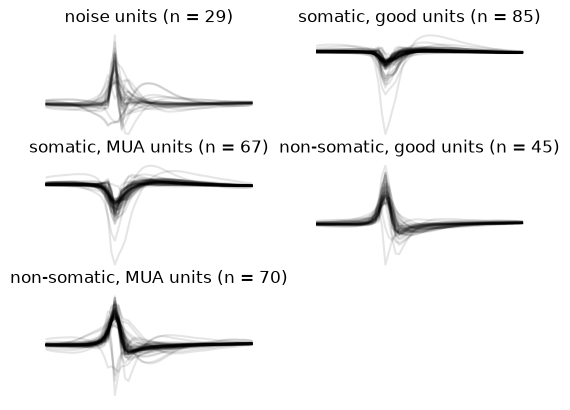

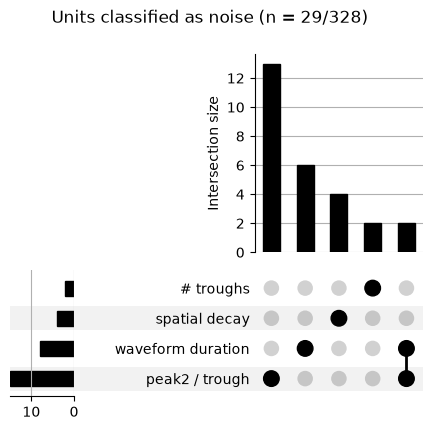

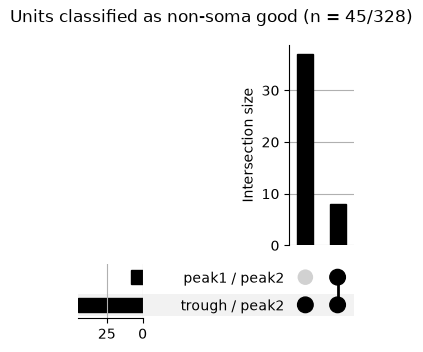

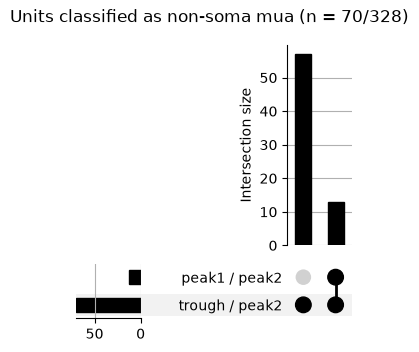

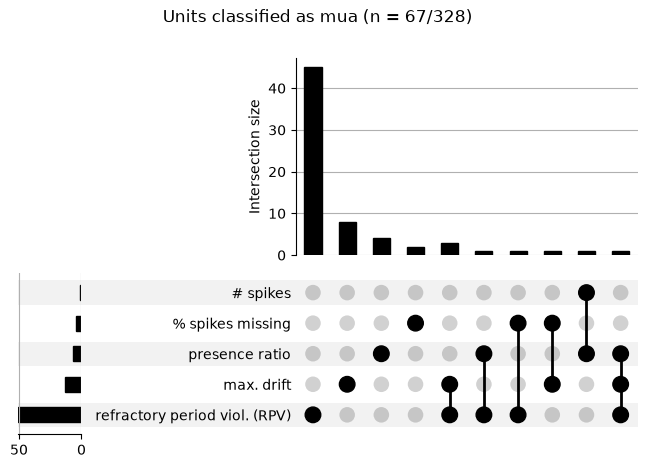

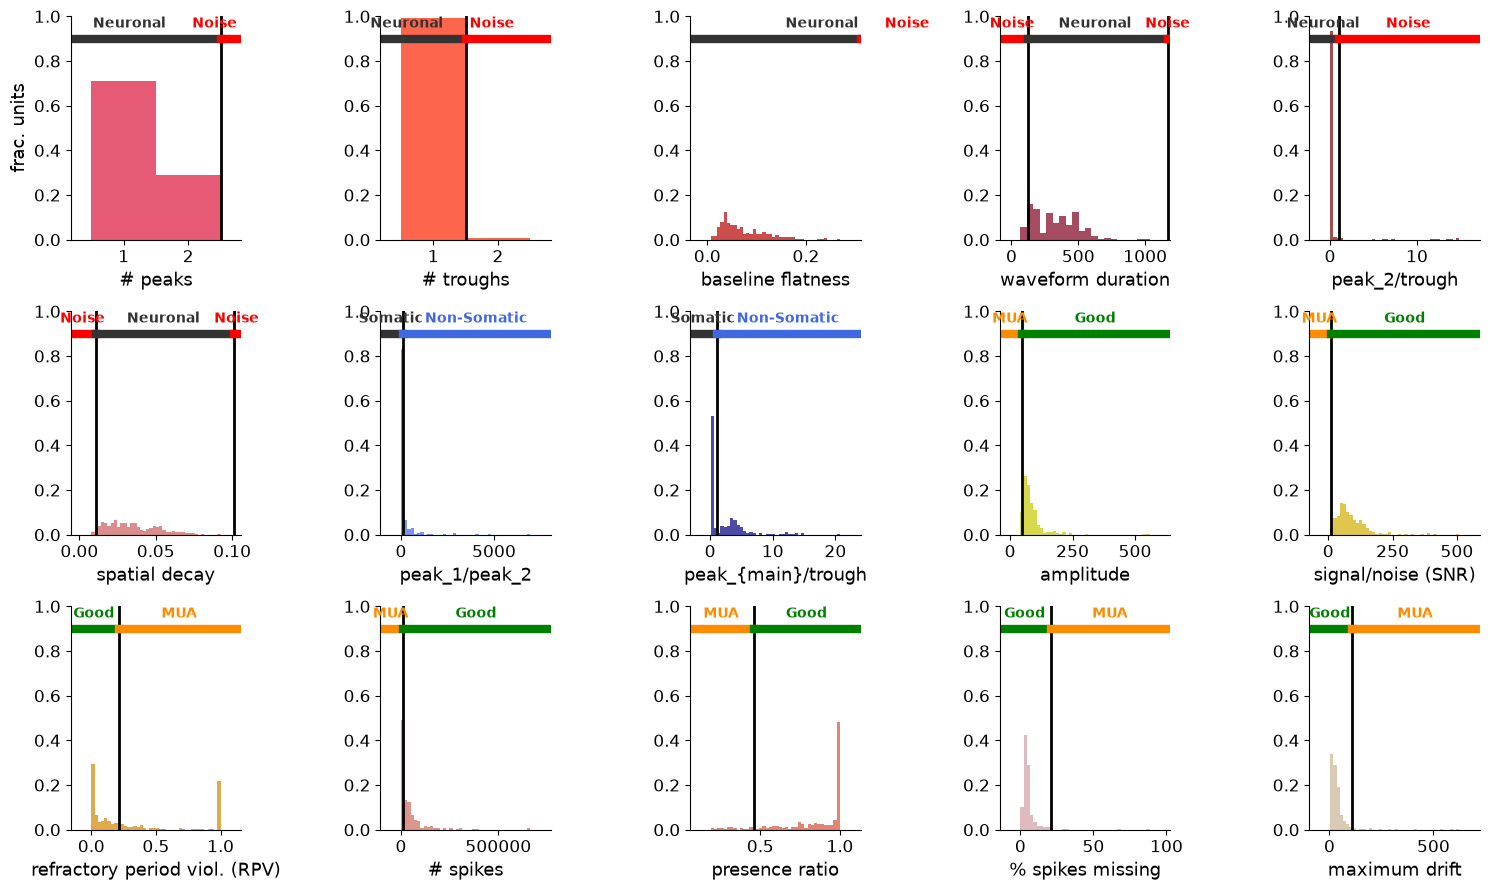


Saving results...
📁 Saving TSV files to Kilosort directory: Z:/Isabel/data/lhy_implants/TRQ82/TRQ82_260810/TRQ82_260810_111419//kilosort4/
All expected metrics were successfully saved.


In [18]:
(quality_metrics, param, unit_type, unit_type_string) = bc.run_bombcell(ks_dir, save_path, param)